<a href="https://colab.research.google.com/github/glwat/Durham_Masters/blob/main/Crossformer_In_Built_Demonstration_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Codeblock D001: Install Python 3.7 in Colab

!sudo apt-get update
!sudo apt-get install python3.7 python3.7-distutils python3.7-dev

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.2 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:10 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,432 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,929 kB]
Hit:13 https://ppa.launchpadcontent.net/graphics-

In [ ]:
#@title Codeblock D002: Install pip for Python 3.7

!wget https://bootstrap.pypa.io/pip/3.7/get-pip.py
!python3.7 get-pip.py

--2026-03-12 12:29:20--  https://bootstrap.pypa.io/pip/3.7/get-pip.py
Resolving bootstrap.pypa.io (bootstrap.pypa.io)... 151.101.0.175, 151.101.64.175, 151.101.128.175, ...
Connecting to bootstrap.pypa.io (bootstrap.pypa.io)|151.101.0.175|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2636033 (2.5M) [text/x-python]
Saving to: ‘get-pip.py’

get-pip.py          100%[===================>]   2.51M  --.-KB/s    in 0.04s   

2026-03-12 12:29:20 (67.9 MB/s) - ‘get-pip.py’ saved [2636033/2636033]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 804.0/804.0 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.4/65.4 kB 8.1 MB/s eta 0:00:00


In [ ]:
#@title Codeblock D003: Define Python 3.7 interpreter variable

PY = "python3.7"

In [ ]:
#@title Codeblock D004: Install exact Crossformer dependencies (NumPy, pandas, einops)

!$PY -m pip install numpy==1.20.3
!$PY -m pip install pandas==1.3.2
!$PY -m pip install einops==0.4.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 47.4 MB/s eta 0:00:00


In [ ]:
#@title Codeblock D005: Install exact PyTorch 1.8.1 + CUDA 11.1 wheels

!$PY -m pip install torch==1.8.1+cu111 \
    torchvision==0.9.1+cu111 \
    torchaudio==0.8.1 \
    -f https://download.pytorch.org/whl/torch_stable.html

Looking in links: https://download.pytorch.org/whl/torch_stable.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 GB 864.4 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 72.4 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of typing-extensions to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 33.9 MB/s eta 0:00:00


In [ ]:
#@title Codeblock D006: Clone Crossformer repository and enter directory

!git clone https://github.com/thinklab-sjtu/crossformer.git
%cd crossformer

Cloning into 'crossformer'...
remote: Enumerating objects: 81, done.
remote: Counting objects: 100% (41/41), done.
remote: Compressing objects: 100% (36/36), done.
remote: Total 81 (delta 8), reused 5 (delta 5), pack-reused 40 (from 1)
Receiving objects: 100% (81/81), 2.28 MiB | 6.75 MiB/s, done.
Resolving deltas: 100% (19/19), done.
/content/crossformer


In [ ]:
#@title Codeblock D007: Train Crossformer model using Python 3.7

!$PY main_crossformer.py \
    --data ETTh1 \
    --in_len 168 \
    --out_len 24 \
    --seg_len 6 \
    --itr 1


Args in experiment:
Namespace(baseline=False, batch_size=32, checkpoints='./checkpoints/', d_ff=512, d_model=256, data='ETTh1', data_dim=7, data_path='ETTh1.csv', data_split=[8640, 2880, 2880], devices='0,1,2,3', dropout=0.2, e_layers=3, factor=10, gpu=0, in_len=168, itr=1, learning_rate=0.0001, lradj='type1', n_heads=4, num_workers=0, out_len=24, patience=3, root_path='./datasets/', save_pred=False, seg_len=6, train_epochs=20, use_gpu=True, use_multi_gpu=False, win_size=2)
Use GPU: cuda:0
>>>>>>>start training : Crossformer_ETTh1_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0>>>>>>>>>>>>>>>>>>>>>>>>>>
train 8449
val 2857
test 2857
	iters: 100, epoch: 1 | loss: 0.3942986
	speed: 0.1071s/iter; left time: 557.1074s
	iters: 200, epoch: 1 | loss: 0.3476273
	speed: 0.1133s/iter; left time: 577.8264s
Epoch: 1 cost time: 29.64316964149475
Epoch: 1, Steps: 265 | Train Loss: 0.4635413 Vali Loss: 0.8081421 Test Loss: 0.6153470
Validation loss decreased (inf --> 0.808142).  Saving model ...
	iters: 

In [ ]:
#@title Codeblock D008: List checkpoint folders

!ls checkpoints

Crossformer_ETTh1_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0
Crossformer_Weather_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0


In [ ]:
#@title Codeblock D009: Evaluate trained Crossformer model

!$PY eval_crossformer.py \
    --checkpoint_root ./checkpoints \
    --setting_name Crossformer_ETTh1_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0

Use GPU: cuda:0
mse:0.3132598400115967, mae:0.3781715929508209


In [ ]:
#@title Codeblock D010: Evaluate model and save predictions

!$PY eval_crossformer.py \
    --checkpoint_root ./checkpoints \
    --setting_name Crossformer_Weather_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0 \
    --save_pred

Use GPU: cuda:0
mse:0.3132598400115967, mae:0.3781715929508209


In [ ]:
#@title Codeblock D011: Load prediction and ground-truth arrays

import os

results_dir = "./results/Crossformer_Weather_il168_ol24_sl6_win2_fa10_dm256_nh4_el3_itr0"
os.listdir(results_dir)

['true.npy', 'pred.npy', 'metric.log', 'metrics.npy']

In [ ]:
import numpy as np

pred = np.load(f"{results_dir}/pred.npy")
true = np.load(f"{results_dir}/true.npy")

pred.shape, true.shape

((3461, 24, 7), (3461, 24, 7))

In [ ]:
#@title Codeblock D014: Apply publication-grade matplotlib styling

plt.style.use('seaborn-v0_8-whitegrid')

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 14
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['legend.frameon'] = False

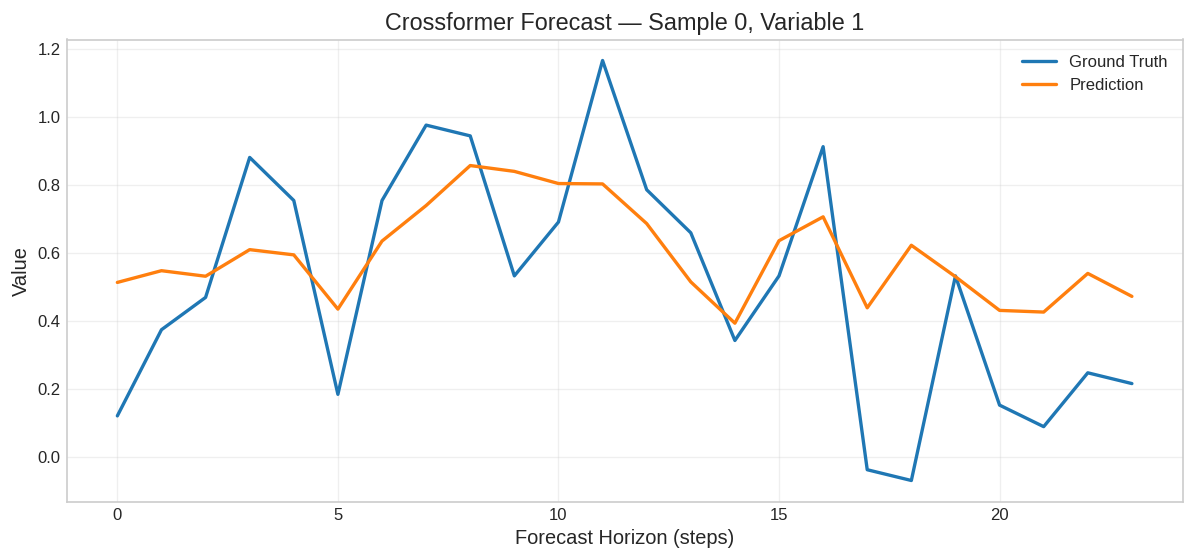

In [ ]:
#@title Codeblock D012: Plot single-sample forecast for one variable

import matplotlib.pyplot as plt

sample = 0   # choose which test sample to plot
var = 1      # choose which variable (0–6 for ETTh1)

plt.figure(figsize=(12, 5))
plt.plot(true[sample, :, var], label="Ground Truth", linewidth=2)
plt.plot(pred[sample, :, var], label="Prediction", linewidth=2)
plt.title(f"Crossformer Forecast — Sample {sample}, Variable {var}")
plt.xlabel("Forecast Horizon (steps)")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

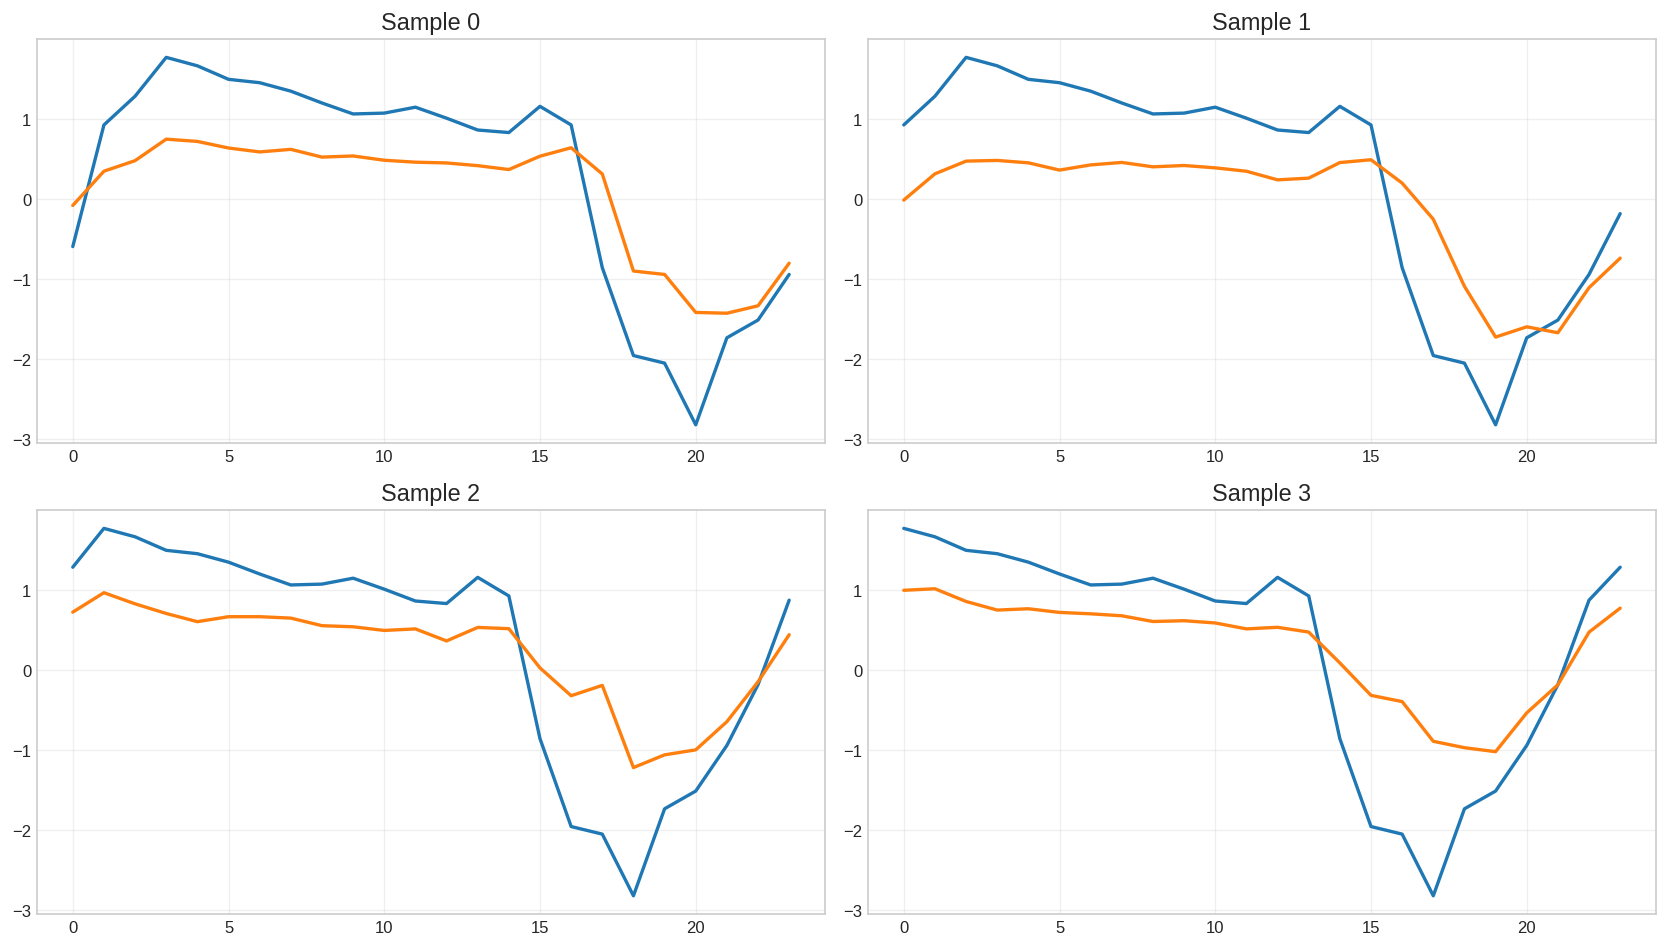

In [ ]:
#@title Codeblock D013: Plot multiple samples in a grid

num_samples = 4
var = 0

plt.figure(figsize=(14, 8))

for i in range(num_samples):
    plt.subplot(2, 2, i+1)
    plt.plot(true[i, :, var], label="True", linewidth=2)
    plt.plot(pred[i, :, var], label="Pred", linewidth=2)
    plt.title(f"Sample {i}")
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()